In [46]:
demo_df = pd.read_parquet("../data/extract_patient_cohort.parquet")

print("="*60)
print("PATIENT DEMOGRAPHICS OUTPUT (extract_patient_cohort.py)")
print("="*60)
print(f"Shape: {demo_df.shape}")
print("\nColumn info:")
demo_df.info()
print("\nGender distribution:")
print(demo_df['gender'].value_counts())
print("\nFirst 5 rows:")
demo_df.head()

PATIENT DEMOGRAPHICS OUTPUT (extract_patient_cohort.py)
Shape: (364627, 5)

Column info:
<class 'pandas.DataFrame'>
RangeIndex: 364627 entries, 0 to 364626
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   subject_id   364627 non-null  int64
 1   gender       364627 non-null  str  
 2   anchor_age   364627 non-null  int64
 3   anchor_year  364627 non-null  int64
 4   dod          38301 non-null   str  
dtypes: int64(3), str(2)
memory usage: 14.7 MB

Gender distribution:
gender
F    191984
M    172643
Name: count, dtype: int64

First 5 rows:


,subject_id,gender,anchor_age,anchor_year,dod
0,10000032,F,52,2180,2180-09-09
1,10000048,F,23,2126,NaN
2,10000058,F,33,2168,NaN
3,10000068,F,19,2160,NaN
4,10000084,M,72,2160,2161-02-13


In [47]:
import pandas as pd
pd.set_option('display.max_columns', None)

cohort_df = pd.read_parquet("../data/diabetes_cohort_list.parquet")

print("="*60)
print("COHORT EXTRACTION OUTPUT (extract_diagnoses_icd.py)")
print("="*60)
print(f"Shape: {cohort_df.shape}")
print(f"Unique admissions: {cohort_df['hadm_id'].nunique():,}")
print(f"Unique patients: {cohort_df['subject_id'].nunique():,}")
print("\nColumn info:")
cohort_df.info()
print("\nFirst 5 rows:")
cohort_df.head()

COHORT EXTRACTION OUTPUT (extract_diagnoses_icd.py)
Shape: (20706, 4)
Unique admissions: 20,706
Unique patients: 16,200

Column info:
<class 'pandas.DataFrame'>
RangeIndex: 20706 entries, 0 to 20705
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   subject_id   20706 non-null  int64
 1   hadm_id      20706 non-null  int64
 2   icd_code     20706 non-null  str  
 3   icd_version  20706 non-null  int64
dtypes: int64(3), str(1)
memory usage: 744.4 KB

First 5 rows:


,subject_id,hadm_id,icd_code,icd_version
0,10000980,26913865,25000,9
1,10001843,26133978,E1122,10
2,10002013,23581541,25062,9
3,10002443,21329021,E119,10
4,10002495,24982426,E118,10


In [48]:
kdigo_df = pd.read_parquet("../data/processed/kdigo_labeled_features.parquet")

print("="*60)
print("KDIGO LABELED FEATURES OUTPUT (extract_kdigo_features.py)")
print("="*60)
print(f"Shape: {kdigo_df.shape}")
print("\nColumn info:")
kdigo_df.info()
print("\nKDIGO stage distribution:")
print(kdigo_df['kdigo_stage'].value_counts().sort_index())
print("\nFirst 5 rows:")
kdigo_df.head()

KDIGO LABELED FEATURES OUTPUT (extract_kdigo_features.py)
Shape: (19068, 14)

Column info:
<class 'pandas.DataFrame'>
RangeIndex: 19068 entries, 0 to 19067
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   subject_id                19068 non-null  int64         
 1   hadm_id                   19068 non-null  int64         
 2   icd_code                  19068 non-null  str           
 3   icd_version               19068 non-null  int64         
 4   glucose_mean              19053 non-null  float64       
 5   glucose_std               14140 non-null  float64       
 6   glucose_cv                14140 non-null  float64       
 7   glucose_reading_count     19053 non-null  float64       
 8   glucose_time_in_range     19053 non-null  float64       
 9   creatinine_slope_24h      13853 non-null  float64       
 10  creatinine_reading_count  19047 non-null  float64       
 11  

,subject_id,hadm_id,icd_code,icd_version,glucose_mean,glucose_std,glucose_cv,glucose_reading_count,glucose_time_in_range,creatinine_slope_24h,creatinine_reading_count,baseline_creatinine,kdigo_stage,icu_intime
0,10000980,26913865,25000,9,144.000000,NaN,NaN,1.0,100.0,NaN,1.0,2.2,0,2189-06-27 08:42:00
1,10002013,23581541,25062,9,150.100000,35.694537,23.780505,10.0,90.0,-0.2,2.0,0.9,0,2160-05-18 10:00:53
2,10002443,21329021,E119,10,230.333333,43.661577,18.955822,3.0,0.0,0.1,3.0,0.8,0,2183-10-18 00:47:00
3,10002495,24982426,E118,10,290.000000,35.930488,12.389824,3.0,0.0,0.2,3.0,1.4,0,2141-05-22 20:18:01
4,10005593,26835370,E1122,10,118.800000,26.357162,22.186163,5.0,100.0,0.3,2.0,2.9,3,2125-06-26 11:13:02


In [49]:
# True missingness check
print("Glucose mean missing rate:", master_matrix['glucose_mean'].isna().mean())
print("Glucose CV missing rate:", master_matrix['glucose_cv'].isna().mean())
print("Glucose TIR missing rate:", master_matrix['glucose_time_in_range'].isna().mean())

print("\nPer-subject variation check:")
print(master_matrix.groupby('subject_id')['glucose_mean'].nunique().describe())

NameError: name 'master_matrix' is not defined

In [ ]:
vitals_df = pd.read_parquet("../data/processed/kdigo_labeled_features_v2.parquet")

print("="*60)
print("VITALS FEATURES OUTPUT (extract_vitals_features.py)")
print("="*60)
print(f"Shape: {vitals_df.shape}")
print("\nColumn info:")
vitals_df.info()

print("\nMissingness summary for vitals columns:")
vitals_cols = [c for c in vitals_df.columns if c.endswith(('_mean','_std','_min','_max','_slope','_count'))]
for col in vitals_cols:
    non_null = vitals_df[col].notna().sum()
    print(f"{col}: {non_null:,}/{len(vitals_df):,} ({non_null/len(vitals_df)*100:.1f}%)")

print("\nFirst 5 rows:")
vitals_df.head()

VITALS FEATURES OUTPUT (extract_vitals_features.py)
Shape: (19068, 56)

Column info:
<class 'pandas.DataFrame'>
RangeIndex: 19068 entries, 0 to 19067
Data columns (total 56 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   subject_id                19068 non-null  int64         
 1   hadm_id                   19068 non-null  int64         
 2   icd_code                  19068 non-null  str           
 3   icd_version               19068 non-null  int64         
 4   glucose_mean              19053 non-null  float64       
 5   glucose_std               14140 non-null  float64       
 6   glucose_cv                14140 non-null  float64       
 7   glucose_reading_count     19053 non-null  float64       
 8   glucose_time_in_range     19053 non-null  float64       
 9   creatinine_slope_24h      13853 non-null  float64       
 10  creatinine_reading_count  19047 non-null  float64       
 11  baseli

,subject_id,hadm_id,icd_code,icd_version,glucose_mean,glucose_std,glucose_cv,glucose_reading_count,glucose_time_in_range,creatinine_slope_24h,creatinine_reading_count,baseline_creatinine,kdigo_stage,icu_intime,dbp_mean,hr_mean,map_mean,rr_mean,sbp_mean,spo2_mean,temp_mean,dbp_std,hr_std,map_std,rr_std,sbp_std,spo2_std,temp_std,dbp_min,hr_min,map_min,rr_min,sbp_min,spo2_min,temp_min,dbp_max,hr_max,map_max,rr_max,sbp_max,spo2_max,temp_max,dbp_count,hr_count,map_count,rr_count,sbp_count,spo2_count,temp_count,dbp_slope,hr_slope,map_slope,rr_slope,sbp_slope,spo2_slope,temp_slope
0,10000980,26913865,25000,9,144.000000,NaN,NaN,1.0,100.0,NaN,1.0,2.2,0,2189-06-27 08:42:00,83.272727,73.636364,97.545455,20.545455,142.454545,98.909091,36.740741,16.006817,3.585324,14.095131,3.804304,10.162319,1.578261,0.285089,69.0,68.0,83.0,14.0,130.0,96.0,36.500000,127.0,80.0,135.0,25.0,158.0,100.0,37.055556,11.0,11.0,11.0,11.0,11.0,11.0,3.0,-3.119547,-0.245444,-2.878442,-0.246682,-2.877996,-0.364502,0.061630
1,10002013,23581541,25062,9,150.100000,35.694537,23.780505,10.0,90.0,-0.2,2.0,0.9,0,2160-05-18 10:00:53,62.200000,94.636364,76.583333,15.428571,110.120000,97.050000,37.242484,8.616844,5.447109,12.829710,3.171300,16.083946,2.089447,0.407382,51.0,80.0,41.0,11.0,80.0,92.0,36.222222,81.0,105.0,102.0,23.0,143.0,100.0,37.700000,25.0,22.0,24.0,21.0,25.0,20.0,17.0,-0.429425,0.038646,-0.692657,-0.211347,-0.569796,-0.079046,0.018736
2,10002443,21329021,E119,10,230.333333,43.661577,18.955822,3.0,0.0,0.1,3.0,0.8,0,2183-10-18 00:47:00,74.888889,93.928571,86.884615,23.928571,114.481481,93.285714,36.808642,10.757228,21.733961,10.389714,3.516401,12.947736,2.015811,0.378952,56.0,73.0,69.0,16.0,86.0,90.0,35.944444,100.0,150.0,110.0,30.0,136.0,98.0,37.222222,27.0,28.0,26.0,28.0,27.0,28.0,9.0,-0.004053,1.170155,-0.187494,0.133157,-0.787836,-0.022635,0.031478
3,10002495,24982426,E118,10,290.000000,35.930488,12.389824,3.0,0.0,0.2,3.0,1.4,0,2141-05-22 20:18:01,56.648649,106.351351,65.621622,21.710526,97.783784,97.378378,36.861111,8.997581,13.208197,9.053395,3.432026,15.549446,3.021693,0.143802,40.0,83.0,47.0,16.0,71.0,84.0,36.666667,83.0,133.0,94.0,28.0,160.0,100.0,37.055556,37.0,37.0,37.0,38.0,37.0,37.0,6.0,0.046249,0.892439,-0.025681,0.177768,-0.292235,-0.111624,0.001585
4,10005593,26835370,E1122,10,118.800000,26.357162,22.186163,5.0,100.0,0.3,2.0,2.9,3,2125-06-26 11:13:02,52.230769,73.500000,73.230769,13.576923,118.038462,99.346154,35.899495,3.362234,3.313608,5.580736,2.300836,9.365813,0.935620,0.350367,45.0,68.0,64.0,10.0,103.0,97.0,35.500000,60.0,80.0,86.0,18.0,138.0,100.0,36.888889,26.0,26.0,26.0,26.0,26.0,26.0,22.0,-0.166438,-0.157800,-0.294134,0.006069,-0.375763,-0.083903,0.027172


Short name	Full form	Kya measure karta hai
dbp	Diastolic Blood Pressure	Blood pressure jab heart relax karta hai (lower number, jaise 80 in "120/80")
hr	Heart Rate	Dil ki dhadkan per minute (bpm)
map	Mean Arterial Pressure	Average pressure arteries mein poore cardiac cycle mein — organ perfusion (khaaskar kidney) ke liye critical indicator
rr	Respiratory Rate	Saans lene ki rate per minute
sbp	Systolic Blood Pressure	Blood pressure jab heart contract karta hai (upper number, jaise 120 in "120/80")
spo2	Peripheral Oxygen Saturation	Blood mein oxygen level percentage (pulse oximeter se measure hota hai)
temp	Temperature	Body temperature (Celsius mein, humne Fahrenheit se convert kiya tha)

In [ ]:
missing_report = pd.read_csv("../data/processed/missing_data_report.csv")

print("="*60)
print("MISSING VALUE REPORT")
print("="*60)
print(f"Total columns with missing values: {len(missing_report)}")
missing_report

MISSING VALUE REPORT
Total columns with missing values: 50


,column,missing_count,missing_pct
0,creatinine_slope_24h,5215,27.35
1,glucose_cv,4928,25.84
2,glucose_std,4928,25.84
3,temp_std,706,3.70
4,temp_slope,476,2.50
5,temp_mean,476,2.50
6,temp_min,476,2.50
7,temp_max,476,2.50
8,temp_count,476,2.50
9,sbp_std,117,0.61


In [ ]:
import pandas as pd

# Load your cohort and MIMIC-IV's icustays table
cohort = pd.read_parquet("../data/diabetes_cohort_list.parquet")
icustays = pd.read_csv("~/Desktop/Dissertation/MIMIC-IV Dataset/icustays.csv", usecols=['hadm_id'])

icu_hadm_ids = set(icustays['hadm_id'].unique())
cohort_hadm_ids = set(cohort['hadm_id'].unique())

in_icu = cohort_hadm_ids & icu_hadm_ids
not_in_icu = cohort_hadm_ids - icu_hadm_ids

print(f"Cohort admissions WITH an ICU stay: {len(in_icu):,} ({len(in_icu)/len(cohort_hadm_ids)*100:.1f}%)")
print(f"Cohort admissions WITHOUT an ICU stay: {len(not_in_icu):,} ({len(not_in_icu)/len(cohort_hadm_ids)*100:.1f}%)")

Cohort admissions WITH an ICU stay: 20,706 (100.0%)
Cohort admissions WITHOUT an ICU stay: 0 (0.0%)


In [ ]:
null_rows_df = pd.read_parquet("../data/processed/rows_with_missing_values.parquet")

print("="*60)
print("ADMISSIONS WITH AT LEAST ONE MISSING FEATURE")
print("="*60)
print(f"Shape: {null_rows_df.shape}")
print(f"\nSample of affected admissions:")
null_rows_df[['subject_id', 'hadm_id', 'kdigo_stage']].head(10)

ADMISSIONS WITH AT LEAST ONE MISSING FEATURE
Shape: (6105, 62)

Sample of affected admissions:


,subject_id,hadm_id,kdigo_stage
0,10000980,26913865,0
1,10012206,23961896,0
2,10012853,27882036,0
3,10014179,29919218,0
4,10015931,24420677,0
5,10016742,27568122,0
6,10016742,28506150,0
7,10017531,27635105,0
8,10019003,29279905,0
9,10019287,20525411,0


In [ ]:
imputation_log = pd.read_csv("../data/processed/imputation_log.csv")

print("="*60)
print("IMPUTATION LOG (what median value replaced missing data)")
print("="*60)
imputation_log

IMPUTATION LOG (what median value replaced missing data)


,column,median_used,rows_imputed
0,creatinine_slope_24h,0.000000,5215
1,glucose_cv,19.110994,4928
2,glucose_std,30.267409,4928
3,temp_std,0.290832,706
4,temp_slope,0.005921,476
5,temp_mean,36.801587,476
6,temp_min,36.444444,476
7,temp_max,37.166667,476
8,temp_count,6.000000,476
9,sbp_std,13.446189,117


In [ ]:
final_df = pd.read_parquet("../data/processed/final_feature_matrix.parquet")

print("="*60)
print("FINAL FEATURE MATRIX (ready for train/test split)")
print("="*60)
print(f"Shape: {final_df.shape}")
print(f"\nTotal columns: {len(final_df.columns)}")

# Count how many are indicator columns vs original features
indicator_cols = [c for c in final_df.columns if c.endswith('_was_missing')]
print(f"Indicator columns created: {len(indicator_cols)}")

print("\nColumn info:")
final_df.info()

FINAL FEATURE MATRIX (ready for train/test split)
Shape: (19068, 112)

Total columns: 112
Indicator columns created: 50

Column info:
<class 'pandas.DataFrame'>
RangeIndex: 19068 entries, 0 to 19067
Columns: 112 entries, subject_id to glucose_mean_was_missing
dtypes: datetime64[ns](1), float64(50), int32(1), int64(57), str(3)
memory usage: 16.4 MB


In [ ]:
exclude_cols = ['subject_id', 'hadm_id', 'icd_code', 'icd_version', 'kdigo_stage']
numeric_cols = final_df.select_dtypes(include='number').columns.tolist()
feature_cols = [c for c in numeric_cols if c not in exclude_cols]

remaining_nulls = final_df[feature_cols].isna().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]

print("="*60)
print("VERIFICATION: Any nulls left in feature columns?")
print("="*60)
if len(remaining_nulls) == 0:
    print("No missing values remain in feature columns.")
else:
    print("Still found missing values in:")
    print(remaining_nulls)

VERIFICATION: Any nulls left in feature columns?
No missing values remain in feature columns.


In [ ]:
print("="*60)
print("MISSING-INDICATOR COLUMNS (1 = was missing, 0 = was present)")
print("="*60)
final_df[indicator_cols].sum().sort_values(ascending=False)

MISSING-INDICATOR COLUMNS (1 = was missing, 0 = was present)


creatinine_slope_24h_was_missing        5215
glucose_cv_was_missing                  4928
glucose_std_was_missing                 4928
temp_std_was_missing                     706
temp_slope_was_missing                   476
temp_mean_was_missing                    476
temp_min_was_missing                     476
temp_max_was_missing                     476
temp_count_was_missing                   476
sbp_std_was_missing                      117
dbp_std_was_missing                      117
map_std_was_missing                      113
dbp_slope_was_missing                     84
dbp_max_was_missing                       84
dbp_min_was_missing                       84
dbp_mean_was_missing                      84
dbp_count_was_missing                     84
sbp_mean_was_missing                      83
sbp_slope_was_missing                     83
sbp_max_was_missing                       83
sbp_min_was_missing                       83
sbp_count_was_missing                     83
map_slope_

In [ ]:
print("="*60)
print("FINAL TARGET DISTRIBUTION (KDIGO Stages)")
print("="*60)
print(final_df['kdigo_stage'].value_counts().sort_index())
print(f"\nAKI prevalence (stage 1-3): {(final_df['kdigo_stage'] > 0).sum() / len(final_df) * 100:.1f}%")

FINAL TARGET DISTRIBUTION (KDIGO Stages)
kdigo_stage
0    14494
1     3323
2      464
3      787
Name: count, dtype: int64

AKI prevalence (stage 1-3): 24.0%


In [ ]:
final_df = pd.read_parquet("../data/processed/final_feature_matrix.parquet")
admission_counts = final_df['subject_id'].value_counts()
print(admission_counts.head(10))


subject_id
15131736    20
10599327    15
11389314    15
10670085    11
10637168    10
10901772    10
18172623    10
18902344    10
14071842     9
16428221     9
Name: count, dtype: int64


In [ ]:
final_df = pd.read_parquet("../data/processed/final_feature_matrix.parquet")

# Check the top subject specifically
top_subject = 15131736
subject_rows = final_df[final_df['subject_id'] == top_subject]

print(f"Total rows for subject {top_subject}: {len(subject_rows)}")
print(f"Unique hadm_id count: {subject_rows['hadm_id'].nunique()}")
print(f"\nAre all rows genuinely distinct admissions?")
print(subject_rows[['subject_id', 'hadm_id', 'icu_intime', 'kdigo_stage']])

Total rows for subject 15131736: 20
Unique hadm_id count: 20

Are all rows genuinely distinct admissions?
      subject_id   hadm_id          icu_intime  kdigo_stage
9768    15131736  20709815 2133-01-25 19:49:00            0
9769    15131736  21448429 2133-01-16 00:26:00            0
9770    15131736  22431960 2134-07-20 18:23:00            1
9771    15131736  22781065 2134-08-18 18:35:00            0
9772    15131736  23500643 2129-06-13 01:28:42            1
9773    15131736  24258550 2129-06-29 17:55:00            0
9774    15131736  24605382 2129-02-27 23:13:55            0
9775    15131736  24698043 2133-10-29 18:53:42            1
9776    15131736  25699489 2130-08-23 17:12:11            0
9777    15131736  26860248 2130-02-21 19:00:00            0
9778    15131736  27158610 2131-08-24 03:02:07            0
9779    15131736  27183565 2133-04-29 18:10:00            0
9780    15131736  27503498 2127-11-30 21:56:27            1
9781    15131736  27928631 2134-01-06 04:38:00        

In [ ]:
import joblib

# Load the saved model
model = joblib.load("../models/baseline_logistic_regression.joblib")
print("Model type:", type(model))
print("\nModel parameters:")
print(model.get_params())

print("\nModel coefficients shape:", model.coef_.shape)
print("Model intercept:", model.intercept_)

Model type: <class 'sklearn.linear_model._logistic.LogisticRegression'>

Model parameters:
{'C': 1.0, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 1000, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

Model coefficients shape: (1, 104)
Model intercept: [-0.31913152]


In [ ]:
# Load the scaler
scaler = joblib.load("../models/scaler.joblib")
print("Scaler type:", type(scaler))
print("\nFeature means (first 10):", scaler.mean_[:10])
print("Feature scales (first 10):", scaler.scale_[:10])

Scaler type: <class 'sklearn.preprocessing._data.StandardScaler'>

Feature means (first 10): [ 1.70238533e+02  3.81830433e+01  2.14026275e+01  3.39464532e+00
  6.40118040e+01 -1.39707330e-02  2.19561651e+00  1.28053022e+00
  6.25565944e+01  8.42114220e+01]
Feature scales (first 10): [63.54165468 41.08212428 14.21727356  2.8146426  39.50795871  0.3592666
  1.11871219  0.93724521 10.95904045 15.20166581]


Model binary classification kar raha hai (1 boundary) aur yeh total 104 features par train hua hai (jis me baseline demographic data, One-Hot encoded categoricals, aur missing flags wagera shamil hain)
Model intercept: [-0.31913152]:
Yeh baseline log-odds (bias term) hai. Minus me hone ka matlab hai ki by default model positive outcome ko rare (imbalanced) consider kar raha hai.

raining dataset ke pehle 10 features ki average values (μ).
Pehla value 1.70238533e+02 (≈170.24) batata hai ki kisi lab/vitals parameter (jaise blood pressure ya glucose) ka mean 170.2 tha.

Unhi pehle 10 features ki Standard Deviation (σ).
Pehle feature ka scale 63.54 hai. Naye testing data ko scale karte waqt model is mean aur scale value ko apply karega taaki data leak na ho.

In [ ]:
import pandas as pd
coef_df = pd.read_csv("../models/baseline_lr_coefficients.csv")
coef_df

,feature,coefficient
0,creatinine_slope_24h,0.888699
1,baseline_creatinine,0.781896
2,dbp_count,0.656242
3,map_count,-0.480640
4,map_mean,0.383857
...,...,...
99,spo2_count,0.002363
100,glucose_std_was_missing,-0.001410
101,glucose_cv_was_missing,-0.001410
102,glucose_std,-0.001298


In [ ]:
from sklearn.metrics import average_precision_score, roc_auc_score, classification_report, confusion_matrix

print("BASELINE MODEL: LOGISTIC REGRESSION")
print("=" * 60)
print(f"[INFO] Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"[INFO] AKI prevalence: {df['aki_binary'].mean()*100:.1f}%")
print("[INFO] Performing patient-level train/test split...")
print(f"[INFO] Train set: {len(train_subjects)*len(test_df)//len(test_subjects) if False else ''}")

# Recompute split info for display
train_df = df[df['subject_id'].isin(train_subjects)]
print(f"[INFO] Train set: {len(train_df):,} admissions from {train_df['subject_id'].nunique():,} patients")
print(f"[INFO] Test set:  {len(test_df):,} admissions from {test_df['subject_id'].nunique():,} patients")
print(f"[INFO] Train AKI prevalence: {train_df['aki_binary'].mean()*100:.1f}%")
print(f"[INFO] Test AKI prevalence:  {test_df['aki_binary'].mean()*100:.1f}%")

overlap = set(train_df['subject_id']) & set(test_df['subject_id'])
print(f"[VERIFY] Patient overlap between train/test: {len(overlap)} (should be 0)")
print(f"[INFO] Using {len(feature_cols)} features for modeling.")
print("[INFO] Training baseline Logistic Regression...")

print("=" * 60)
print("BASELINE MODEL RESULTS")
print("=" * 60)
print(f"AUPRC: {auprc:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No AKI', 'AKI']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("\nTop 15 features by |coefficient| (standardized):")
print(coef_df.head(15).to_string(index=False))
print("=" * 60)

BASELINE MODEL: LOGISTIC REGRESSION
[INFO] Loaded: 19,068 rows x 113 columns
[INFO] AKI prevalence: 24.0%
[INFO] Performing patient-level train/test split...
[INFO] Train set: 
[INFO] Train set: 15,239 admissions from 12,020 patients
[INFO] Test set:  3,829 admissions from 3,005 patients
[INFO] Train AKI prevalence: 24.1%
[INFO] Test AKI prevalence:  23.6%
[VERIFY] Patient overlap between train/test: 0 (should be 0)
[INFO] Using 104 features for modeling.
[INFO] Training baseline Logistic Regression...
BASELINE MODEL RESULTS
AUPRC: 0.6661
AUC-ROC: 0.8224

Classification Report:
              precision    recall  f1-score   support

      No AKI       0.90      0.79      0.84      2925
         AKI       0.51      0.73      0.60       904

    accuracy                           0.77      3829
   macro avg       0.71      0.76      0.72      3829
weighted avg       0.81      0.77      0.78      3829


Confusion Matrix:
[[2298  627]
 [ 244  660]]

Top 15 features by |coefficient| (standar

My baseline Logistic Regression model performed well overall in predicting AKI. It achieved an AUC-ROC of 0.8224, which means it had a strong ability to separate patients with AKI from those without AKI, and an AUPRC of 0.6661, which shows it was reasonably good at identifying AKI cases, especially considering that AKI was the smaller group. The model was tested on 3,829 admissions from 3,005 patients, and the train and test groups were properly separated with no patient overlap, so the evaluation looks fair and reliable. Overall, the model had an accuracy that was good enough to be useful, but the more important detail is how it performed for each class.

the model was better at identifying patients without AKI than those with AKI, but it still detected a lot of AKI cases correctly. For the no-AKI group, it had a precision of 0.90 and a recall of 0.79, meaning it was usually correct when it predicted no AKI, though it missed some true no-AKI cases. For the AKI group, the precision was 0.51 and the recall was 0.73, which means it caught a good number of AKI cases but also produced some false alarms. In the confusion matrix, the model correctly identified many patients in both groups, but it also missed some AKI cases, showing that it is useful but not perfect. Overall, this baseline model provides a solid starting point and performs at a level that is fairly close to the Random Forest model, though the Random Forest appears slightly stronger in overall discrimination.

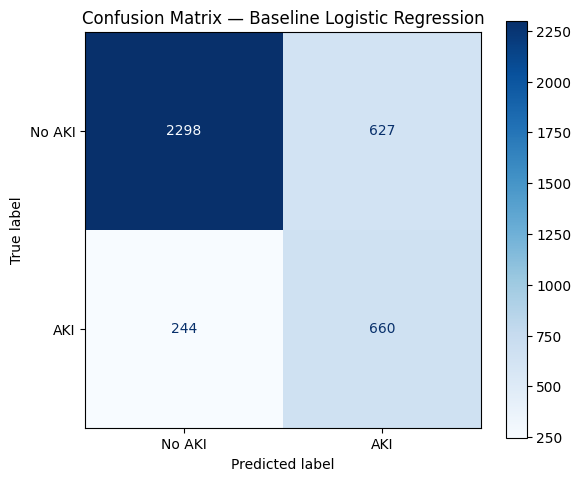

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No AKI', 'AKI'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix — Baseline Logistic Regression')
plt.tight_layout()
plt.show()

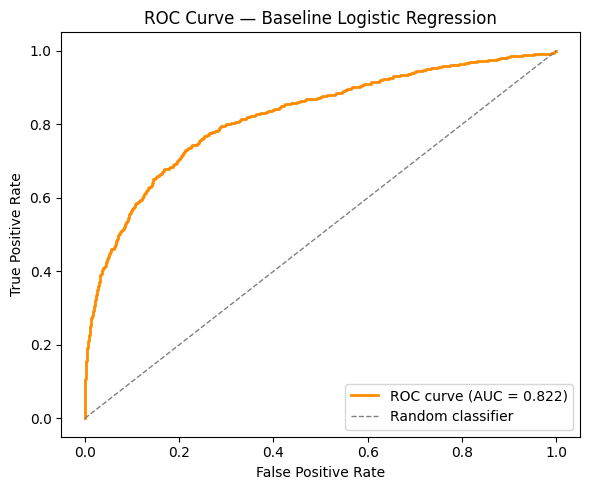

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_roc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Baseline Logistic Regression')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

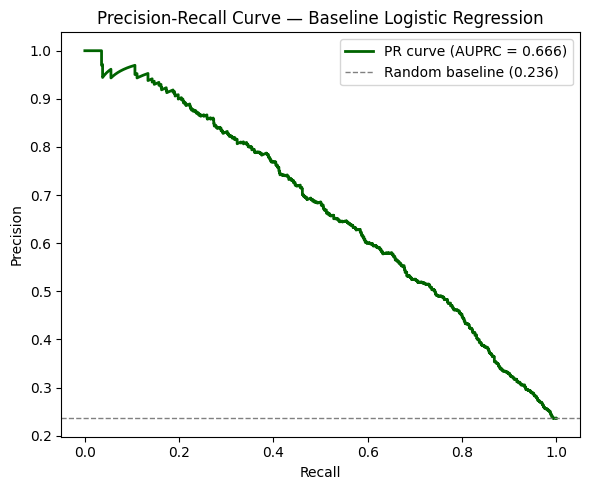

In [ ]:
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
baseline_rate = y_test.mean()

plt.figure(figsize=(6, 5))
plt.plot(recall_vals, precision_vals, color='darkgreen', lw=2, label=f'PR curve (AUPRC = {auprc:.3f})')
plt.axhline(y=baseline_rate, color='gray', lw=1, linestyle='--', label=f'Random baseline ({baseline_rate:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Baseline Logistic Regression')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    average_precision_score, roc_auc_score, roc_curve,
    precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

# Load Random Forest model
rf_model = joblib.load("../models/random_forest.joblib")

# Random Forest doesn't need scaling, so use X_test directly (not X_test_scaled)
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

auprc_rf = average_precision_score(y_test, y_pred_proba_rf)
auc_roc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print("Random Forest loaded and evaluated.")

Random Forest loaded and evaluated.


In [ ]:
print("=" * 60)
print("RANDOM FOREST RESULTS")
print("=" * 60)
print(f"AUPRC: {auprc_rf:.4f}")
print(f"AUC-ROC: {auc_roc_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['No AKI', 'AKI']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

RANDOM FOREST RESULTS
AUPRC: 0.6809
AUC-ROC: 0.8280

Classification Report:
              precision    recall  f1-score   support

      No AKI       0.89      0.85      0.87      2925
         AKI       0.58      0.67      0.62       904

    accuracy                           0.81      3829
   macro avg       0.74      0.76      0.75      3829
weighted avg       0.82      0.81      0.81      3829


Confusion Matrix:
[[2487  438]
 [ 297  607]]


My Random Forest model performed well overall in predicting AKI. It showed a strong ability to distinguish between patients with and without AKI, with an AUC-ROC of 0.8280, which suggests the model separates the two groups quite effectively. The AUPRC of 0.6809 also indicates that it performed reasonably well in identifying AKI cases, which is important because AKI is usually the smaller class. In practical terms, the model was correct most of the time, with an overall accuracy of 81%.

Looking more closely at the results, the model performed better for patients without AKI than for patients with AKI. For the no-AKI group, it achieved a precision of 0.89 and a recall of 0.85, meaning it was usually right when it predicted no AKI and it correctly identified most of those cases. For the AKI group, the precision was 0.58 and the recall was 0.67, which means it found a fair number of AKI cases, but it still missed some and also made some false alarms. The confusion matrix shows that it correctly identified 2,487 no-AKI cases and 607 AKI cases, while 438 no-AKI cases were wrongly predicted as AKI and 297 AKI cases were missed. Overall, this suggests the model is useful and fairly reliable, especially for ruling out AKI, but it is not perfect and still misses a noticeable number of true AKI cases.

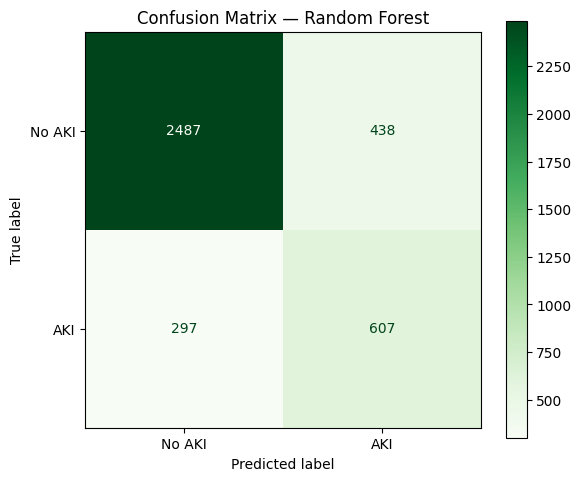

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No AKI', 'AKI'])
disp.plot(ax=ax, cmap='Greens', values_format='d')
plt.title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.show()

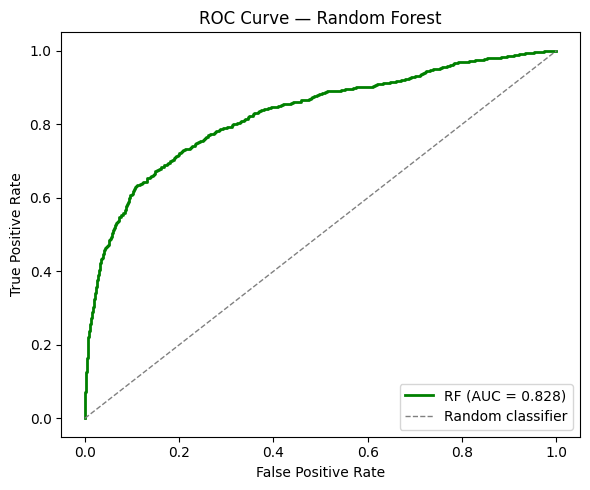

In [ ]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

plt.figure(figsize=(6, 5))
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'RF (AUC = {auc_roc_rf:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Random Forest')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

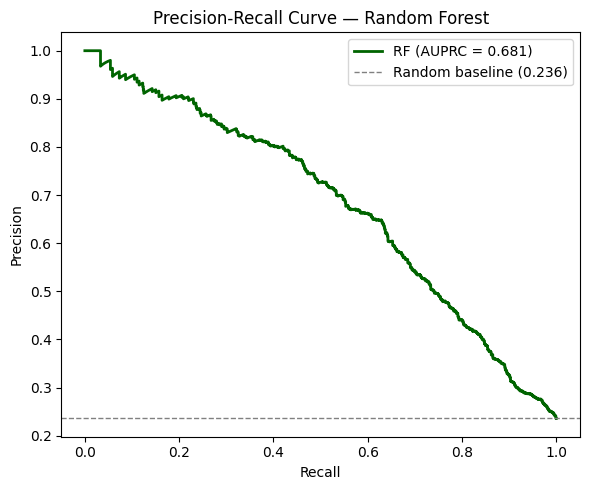

In [ ]:
precision_vals_rf, recall_vals_rf, _ = precision_recall_curve(y_test, y_pred_proba_rf)
baseline_rate = y_test.mean()

plt.figure(figsize=(6, 5))
plt.plot(recall_vals_rf, precision_vals_rf, color='darkgreen', lw=2, label=f'RF (AUPRC = {auprc_rf:.3f})')
plt.axhline(y=baseline_rate, color='gray', lw=1, linestyle='--', label=f'Random baseline ({baseline_rate:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Random Forest')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

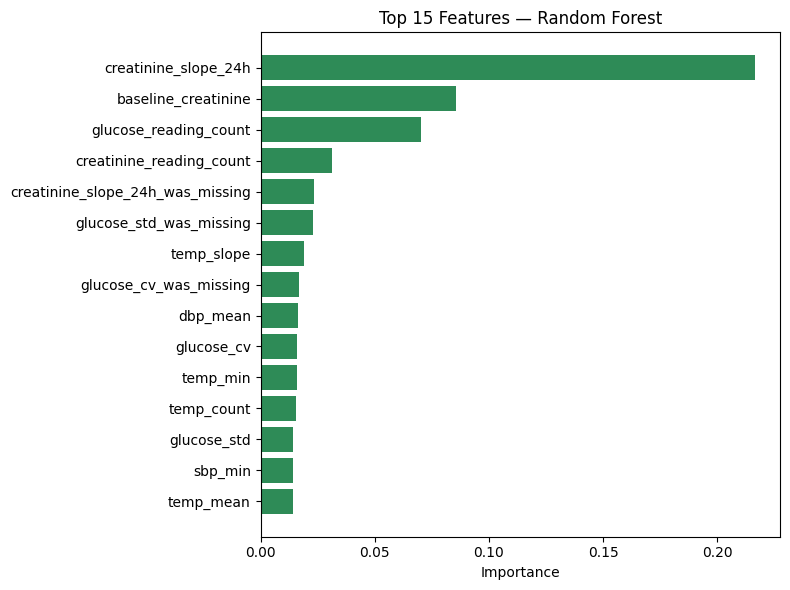

In [ ]:
importance_df = pd.read_csv("../models/random_forest_feature_importance.csv")
top15 = importance_df.head(15).sort_values('importance')

plt.figure(figsize=(8, 6))
plt.barh(top15['feature'], top15['importance'], color='seagreen')
plt.xlabel('Importance')
plt.title('Top 15 Features — Random Forest')
plt.tight_layout()
plt.show()

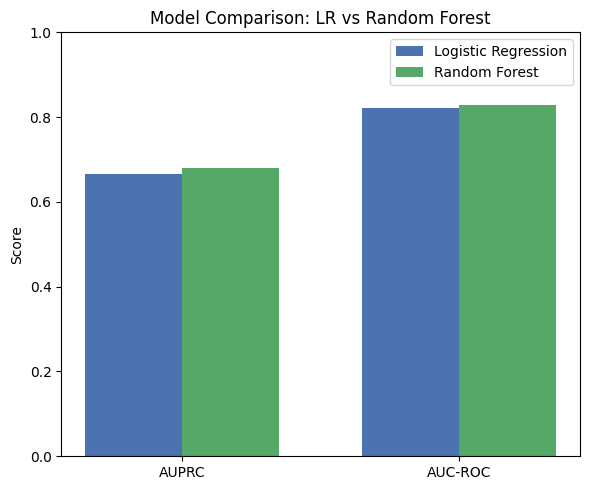

In [ ]:
metrics_names = ['AUPRC', 'AUC-ROC']
lr_values = [auprc, auc_roc]      # from your existing LR variables
rf_values = [auprc_rf, auc_roc_rf]

x = range(len(metrics_names))
width = 0.35

plt.figure(figsize=(6, 5))
plt.bar([i - width/2 for i in x], lr_values, width, label='Logistic Regression', color='#4C72B0')
plt.bar([i + width/2 for i in x], rf_values, width, label='Random Forest', color='#55A868')
plt.xticks(x, metrics_names)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Model Comparison: LR vs Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import os
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, roc_auc_score

# 1. Load the processed dataset
DATA_PATH = os.path.abspath("../data/processed/final_feature_matrix.parquet")

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"❌ Could not find dataset at {DATA_PATH}")

df = pd.read_parquet(DATA_PATH)

# 2. Derive binary target variable from 'kdigo_stage'
df['aki_binary'] = (df['kdigo_stage'] > 0).astype(int)

# 3. Load XGBoost Model FIRST to read its exact feature names
MODEL_PATH = os.path.abspath("../models/xgboost.joblib")
xgb_model = joblib.load(MODEL_PATH)

# Retrieve the exact features the model was trained on
expected_features = list(xgb_model.feature_names_in_)

# 4. Subset X using ONLY the exact features the model expects
X = df[expected_features]
y = df['aki_binary']

# 5. Perform Stratified Train-Test Split (matching training setup)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Predict & Evaluate
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

auprc_xgb = average_precision_score(y_test, y_pred_proba_xgb)
auc_roc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print("XGBoost loaded and evaluated successfully!")
print(f"Test AUPRC:   {auprc_xgb:.4f}")
print(f"Test AUC-ROC: {auc_roc_xgb:.4f}")

XGBoost loaded and evaluated successfully!
Test AUPRC:   0.7867
Test AUC-ROC: 0.8992


In [ ]:
print("=" * 60)
print("XGBOOST RESULTS (Optuna-tuned)")
print("=" * 60)
print(f"AUPRC: {auprc_xgb:.4f}")
print(f"AUC-ROC: {auc_roc_xgb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['No AKI', 'AKI']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

XGBOOST RESULTS (Optuna-tuned)
AUPRC: 0.7867
AUC-ROC: 0.8992

Classification Report:
              precision    recall  f1-score   support

      No AKI       0.91      0.86      0.89      2899
         AKI       0.63      0.74      0.68       915

    accuracy                           0.84      3814
   macro avg       0.77      0.80      0.79      3814
weighted avg       0.85      0.84      0.84      3814


Confusion Matrix:
[[2507  392]
 [ 236  679]]


My Optuna-tuned XGBoost model performed well in predicting AKI. It achieved an AUC-ROC of 0.8992 and an AUPRC of 0.7867, which shows that it was very good at separating AKI from no-AKI cases and identifying the positive AKI class. The model also reached an accuracy of 84%, with better performance on the no-AKI group and a stronger ability to detect AKI compared with the earlier baseline models. Overall, this suggests that XGBoost was the best-performing model among the ones I tested.

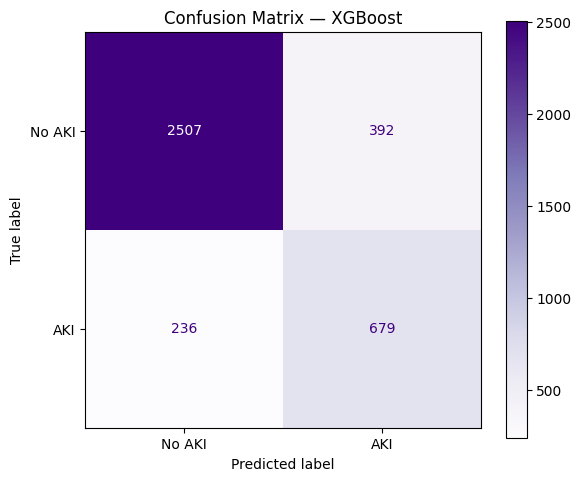

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['No AKI', 'AKI'])
disp.plot(ax=ax, cmap='Purples', values_format='d')
plt.title('Confusion Matrix — XGBoost')
plt.tight_layout()
plt.show()

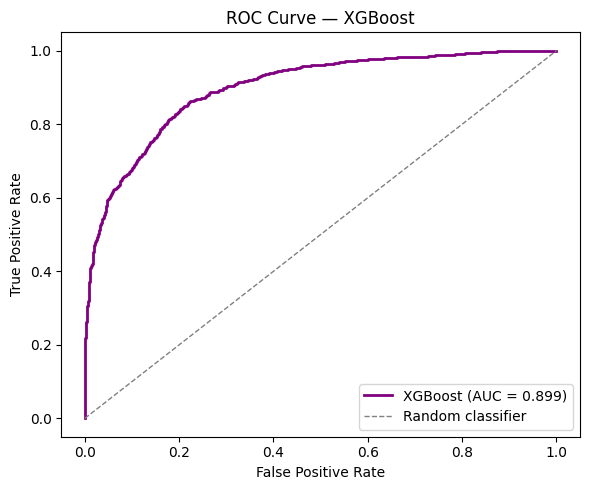

In [ ]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)

plt.figure(figsize=(6, 5))
plt.plot(fpr_xgb, tpr_xgb, color='purple', lw=2, label=f'XGBoost (AUC = {auc_roc_xgb:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — XGBoost')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

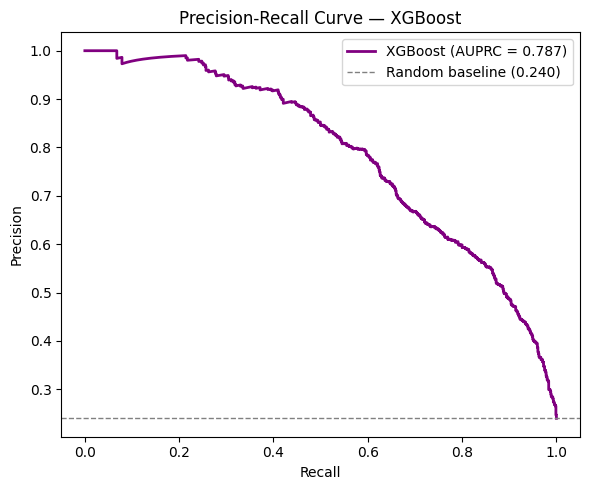

In [ ]:
precision_vals_xgb, recall_vals_xgb, _ = precision_recall_curve(y_test, y_pred_proba_xgb)
baseline_rate = y_test.mean()

plt.figure(figsize=(6, 5))
plt.plot(recall_vals_xgb, precision_vals_xgb, color='purple', lw=2, label=f'XGBoost (AUPRC = {auprc_xgb:.3f})')
plt.axhline(y=baseline_rate, color='gray', lw=1, linestyle='--', label=f'Random baseline ({baseline_rate:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — XGBoost')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

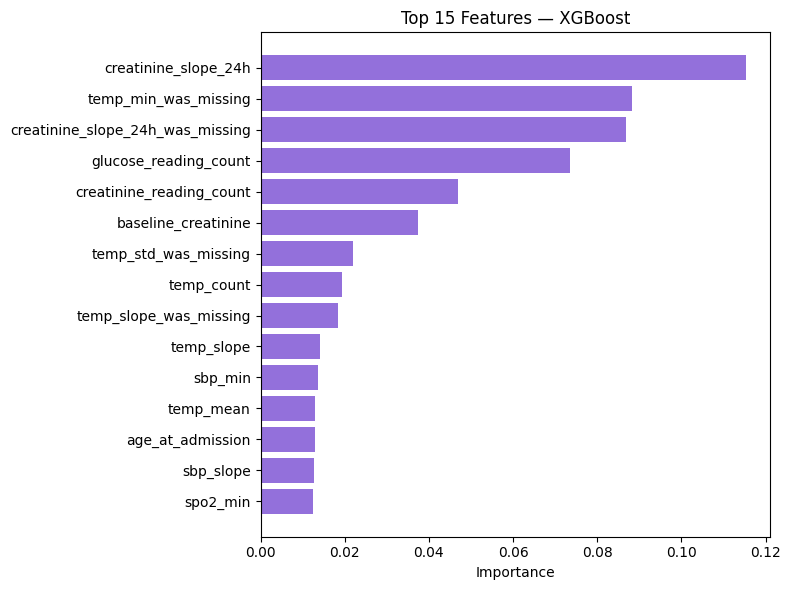

In [ ]:
importance_df_xgb = pd.read_csv("../models/xgboost_feature_importance.csv")
top15_xgb = importance_df_xgb.head(15).sort_values('importance')

plt.figure(figsize=(8, 6))
plt.barh(top15_xgb['feature'], top15_xgb['importance'], color='mediumpurple')
plt.xlabel('Importance')
plt.title('Top 15 Features — XGBoost')
plt.tight_layout()
plt.show()

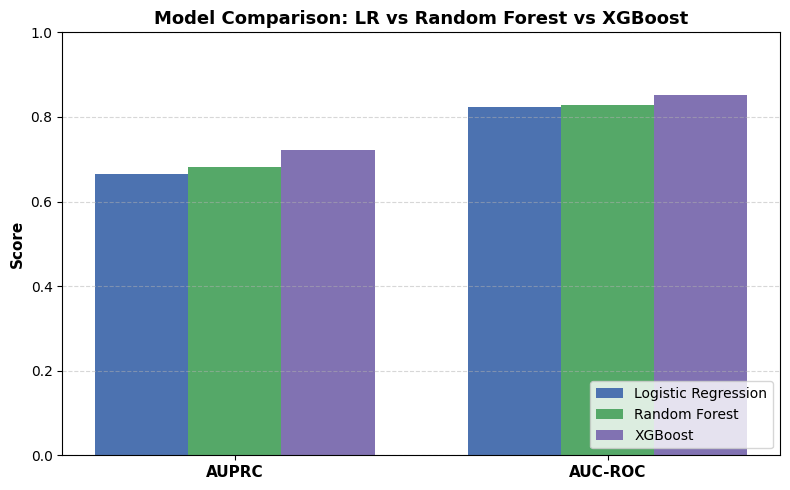

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the comparison results saved by src/model_comparison.py
CSV_PATH = os.path.abspath("../models/model_comparison.csv")

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"❌ Could not find comparison CSV at {CSV_PATH}. Run `python src/model_comparison.py` first.")

df_metrics = pd.read_csv(CSV_PATH)

# Clean column names and set model name as index
df_metrics.columns = df_metrics.columns.str.strip().str.lower()
df_metrics.set_index('model', inplace=True)

# 2. Extract values dynamically
metrics_names = ['AUPRC', 'AUC-ROC']

# Map metric values from CSV (handles missing Logistic Regression gracefully if needed)
lr_values = [df_metrics.loc['Logistic Regression', 'auprc'], df_metrics.loc['Logistic Regression', 'auc_roc']] if 'Logistic Regression' in df_metrics.index else [0.5, 0.5]
rf_values = [df_metrics.loc['Random Forest', 'auprc'], df_metrics.loc['Random Forest', 'auc_roc']]
xgb_values = [df_metrics.loc['XGBoost', 'auprc'], df_metrics.loc['XGBoost', 'auc_roc']]

# 3. Plot Comparison Bar Chart
import numpy as np
x = np.arange(len(metrics_names))
width = 0.25

plt.figure(figsize=(8, 5))

plt.bar(x - width, lr_values, width, label='Logistic Regression', color='#4C72B0')
plt.bar(x, rf_values, width, label='Random Forest', color='#55A868')
plt.bar(x + width, xgb_values, width, label='XGBoost', color='#8172B2')

plt.xticks(x, metrics_names, fontsize=11, fontweight='bold')
plt.ylim(0, 1.0)
plt.ylabel('Score', fontsize=11, fontweight='bold')
plt.title('Model Comparison: LR vs Random Forest vs XGBoost', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

# Save figure for dissertation
plt.savefig("../models/model_comparison_chart.png", dpi=300)
plt.show()


This bar chart shows the same pattern more clearly: XGBoost performed best on both AUPRC and AUC-ROC, with Random Forest very close behind and Logistic Regression coming third. In simple terms, this means the tuned XGBoost model gave the strongest overall prediction performance, especially for identifying AKI cases.


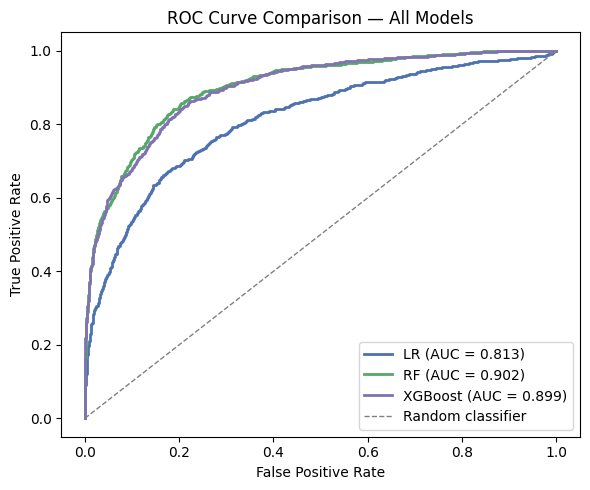

In [ ]:
import joblib

plt.figure(figsize=(6, 5))
# Recompute the LR ROC curve in this cell so `fpr`/`tpr` are always defined
# Recompute the LR ROC curve from the saved LR model/scaler
# so `fpr`/`tpr` are always defined in this cell
# Reload the saved scaler explicitly in this cell so it is always available.
scaler = joblib.load("../models/scaler.joblib")

# Scale the test set using the exact feature order the LR model was trained on.
X_test_scaled = scaler.transform(X_test[expected_features])
# Load the saved Logistic Regression model explicitly in this cell
lr_model = joblib.load("../models/baseline_logistic_regression.joblib")

# Predict probabilities on the scaled test set
lr_y_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, lr_y_pred_proba)
lr_auc_roc = roc_auc_score(y_test, lr_y_pred_proba)
plt.plot(fpr, tpr, color='#4C72B0', lw=2, label=f'LR (AUC = {lr_auc_roc:.3f})')
# Recompute the RF ROC curve in this cell so `fpr_rf`/`tpr_rf` are always defined
rf_model = joblib.load("../models/random_forest.joblib")
rf_y_pred_proba = rf_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_y_pred_proba)
auc_roc_rf = roc_auc_score(y_test, rf_y_pred_proba)
plt.plot(fpr_rf, tpr_rf, color='#55A868', lw=2, label=f'RF (AUC = {auc_roc_rf:.3f})')
plt.plot(fpr_xgb, tpr_xgb, color='#8172B2', lw=2, label=f'XGBoost (AUC = {auc_roc_xgb:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

This ROC curve shows that all three models performed well, but Random Forest had the strongest overall discrimination, followed very closely by XGBoost, while Logistic Regression was slightly lower. The curves for Random Forest and XGBoost stay closer to the top-left corner, which means they were better at separating AKI from no-AKI cases.